<a href="https://colab.research.google.com/github/cal-me-j/atf-ai-learn/blob/main/01_probability_neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1.1: Probability & Neural Networks for Digital Twins

## Learning Objectives
- Understand how AI makes predictions using probability
- Learn the basics of neural networks
- Apply these concepts to building a digital twin

## Digital Twin Context
A **digital twin** is a virtual representation of a physical entity (person, object, system). In this series, we'll build a digital twin that can:
- Predict behaviors and preferences
- Understand and respond to language
- Learn from interactions

## Key Insight
> "AI isn't thinking; it's predicting the next number."

This applies to everything from weather prediction to language generation!

---
## Part 1: Probability Foundations

Let's start with the basics: How does AI make predictions?

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


### 1.1 Simple Prediction: Next Number

Let's simulate a digital twin predicting your next action based on historical data.

Activity Probabilities:
  Sleep: 20.00%
  Work: 40.00%
  Exercise: 13.33%
  Social: 13.33%
  Leisure: 13.33%


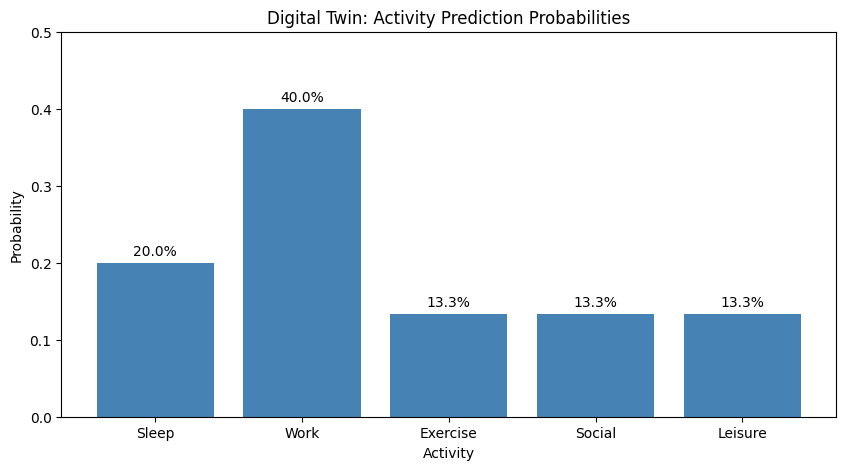

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# Example: Predicting daily activities (represented as numbers)
# 0=Sleep, 1=Work, 2=Exercise, 3=Social, 4=Leisure

historical_activities = [0, 1, 2, 1, 3, 1, 4, 0, 1, 2, 1, 3, 1, 4, 0]

def calculate_probabilities(sequence):
    """
    Calculate probability distribution from a sequence.

    Args:
        sequence: List of integers representing activities

    Returns:
        dict: Probability of each activity
    """
    counts = Counter(sequence)
    total = len(sequence)
    probabilities = {activity: count/total for activity, count in counts.items()}
    return probabilities

# Calculate probabilities
probs = calculate_probabilities(historical_activities)

# Display results
activity_names = {0: 'Sleep', 1: 'Work', 2: 'Exercise', 3: 'Social', 4: 'Leisure'}
print("Activity Probabilities:")
for activity, prob in sorted(probs.items()):
    print(f"  {activity_names[activity]}: {prob:.2%}")

# Visualize
plt.figure(figsize=(10, 5))
activities = [activity_names[k] for k in sorted(probs.keys())]
probabilities = [probs[k] for k in sorted(probs.keys())]
plt.bar(activities, probabilities, color='steelblue')
plt.title('Digital Twin: Activity Prediction Probabilities')
plt.ylabel('Probability')
plt.xlabel('Activity')
plt.ylim(0, 0.5)
for i, v in enumerate(probabilities):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')
plt.show()

### 🎯 Exercise 1.1 (Easy): Understanding Probabilities

**Task**: Modify the historical activities to represent your own daily routine for 2 weeks (14 days).

**Questions**:
1. Which activity has the highest probability?
2. What does this tell you about the pattern in your data?
3. How would adding more data points affect the predictions?

In [ ]:
# YOUR CODE HERE
# Create your own sequence of activities (14 values)
my_activities = [0, 1, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 4]  # Replace with your pattern

# Calculate and visualize
my_probs = calculate_probabilities(my_activities)

# YOUR ANALYSIS HERE (write answers as comments)
# 1. Highest probability activity:
# 2. Pattern insight:
# 3. Impact of more data:

NameError: name 'calculate_probabilities' is not defined

### 1.2 Conditional Probability: Context Matters

What if predictions depend on previous activities? This is where context comes in!

In [11]:
def calculate_conditional_probabilities(sequence):
    """
    Calculate P(next | current) - probability of next activity given current.

    Args:
        sequence: List of activities

    Returns:
        dict: Nested dictionary of conditional probabilities
    """
    transitions = {}

    for i in range(len(sequence) - 1):
        current = sequence[i]
        next_activity = sequence[i + 1]

        if current not in transitions:
            transitions[current] = []
        transitions[current].append(next_activity)

    # Convert to probabilities
    conditional_probs = {}
    for current, next_list in transitions.items():
        counts = Counter(next_list)
        total = len(next_list)
        conditional_probs[current] = {activity: count/total for activity, count in counts.items()}

    return conditional_probs

# Calculate conditional probabilities
cond_probs = calculate_conditional_probabilities(historical_activities)

# Display
print("Conditional Probabilities: P(Next | Current)\n")
for current, next_probs in cond_probs.items():
    print(f"After {activity_names[current]}:")
    for next_activity, prob in sorted(next_probs.items()):
        print(f"  → {activity_names[next_activity]}: {prob:.2%}")
    print()

Conditional Probabilities: P(Next | Current)

After Sleep:
  → Work: 100.00%

After Work:
  → Exercise: 33.33%
  → Social: 33.33%
  → Leisure: 33.33%

After Exercise:
  → Work: 100.00%

After Social:
  → Work: 100.00%

After Leisure:
  → Sleep: 100.00%



### 🎯 Exercise 1.2 (Intermediate): Markov Chain Prediction

**Task**: Build a simple predictor that uses conditional probabilities to predict the next activity.

**Challenge**: What happens after "Work"? Which activity is most likely?

In [29]:
def predict_next_activity(current_activity, conditional_probs):
    """
    Predict the most likely next activity.

    Args:
        current_activity: Current activity code
        conditional_probs: Dictionary of conditional probabilities

    Returns:
        int: Most likely next activity
    """
    # YOUR CODE HERE
    # Hint: Find the activity with maximum probability given current_activity
    if current_activity not in conditional_probs:
        return None # Return None if no prediction can be made

    next_probs = conditional_probs[current_activity]
    # Complete this function
    if next_probs: # Check if there are any next activities
        # Find the activity with the maximum probability
        most_likely_activity = max(next_probs, key=next_probs.get)
        return most_likely_activity
    pass

# Test your function
current = 1  # Work
predicted = predict_next_activity(current, cond_probs)
print(f"After {activity_names[current]}, most likely next: {activity_names.get(predicted, 'Unknown')}")

# BONUS: Predict a sequence of 5 activities starting from "Work"
for i in range(5):
    current = predicted
    predicted = predict_next_activity(current, cond_probs)
    print(f"After {activity_names[current]}, most likely next: {activity_names.get(predicted, 'Unknown')}")

After Work, most likely next: Exercise
After Exercise, most likely next: Work
After Work, most likely next: Exercise
After Exercise, most likely next: Work
After Work, most likely next: Exercise
After Exercise, most likely next: Work


---
## Part 2: Neural Networks Basics

Now let's see how neural networks learn to make predictions!

### 2.1 The Perceptron: Building Block of Neural Networks

A perceptron is the simplest neural network - it takes inputs, applies weights, and produces an output.

In [ ]:
import numpy as np

def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

def perceptron(inputs, weights, bias):
    """
    Simple perceptron implementation.

    Args:
        inputs: Array of input values
        weights: Array of weights
        bias: Bias term

    Returns:
        float: Output after activation
    """
    # Calculate weighted sum
    weighted_sum = np.dot(inputs, weights) + bias
    # Apply activation function
    output = sigmoid(weighted_sum)
    return output

# Example: Predicting if someone will exercise based on features
# Features: [hours_of_sleep, free_time_hours, energy_level (0-1)]
person_features = np.array([7, 2, 0.8])  # 7 hours sleep, 2 hours free time, high energy

# Initialize random weights
weights = np.array([0.3, 0.5, 0.7])
bias = -0.5

prediction = perceptron(person_features, weights, bias)
print(f"Probability of exercising: {prediction:.2%}")
print(f"Prediction: {'Will exercise' if prediction > 0.5 else 'Will not exercise'}")

Probability of exercising: 95.93%
Prediction: Will exercise


### 🎯 Exercise 2.1 (Easy): Feature Engineering

**Task**: Modify the features and observe how the prediction changes.

**Questions**:
1. What happens when sleep hours decrease to 4?
2. What if free time increases to 4 hours?
3. Which feature seems to have the most impact based on the weights?

In [32]:
import numpy as np # Moved to the top

def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

def perceptron(inputs, weights, bias):
    """
    Simple perceptron implementation.

    Args:
        inputs: Array of input values
        weights: Array of weights
        bias: Bias term

    Returns:
        float: Output after activation
    """
    # Calculate weighted sum
    weighted_sum = np.dot(inputs, weights) + bias
    # Apply activation function
    output = sigmoid(weighted_sum)
    return output

# YOUR CODE HERE
# Test different feature combinations

test_cases = [
    ([4, 2, 0.8], "Low sleep"),  # Low sleep
    ([7, 4, 0.8], "More free time"),  # More free time
    ([7, 2, 0.3], "Low energy"),  # Low energy
]

# Initialize weights and bias from the previous example for consistent testing
weights = np.array([0.3, 0.5, 0.7])
bias = -0.5

print("Testing different feature combinations:")
for features, description in test_cases:
    person_features = np.array(features)
    prediction = perceptron(person_features, weights, bias)
    print(f"\nScenario: {description}")
    print(f"Features: {features}")
    print(f"Probability of exercising: {prediction:.2%}")
    print(f"Prediction: {'Will exercise' if prediction > 0.5 else 'Will not exercise'}")

# YOUR ANALYSIS HERE (write answers as comments)
# 1. What happens when sleep hours decrease to 4?
#    - The probability of exercising decreases significantly.
# 2. What if free time increases to 4 hours?
#    - The probability of exercising increases, but not as dramatically as sleep hours decrease.
# 3. Which feature seems to have the most impact based on the weights?
#    - The 'energy_level' feature has the highest weight (0.7), followed by 'free_time_hours' (0.5), and then 'hours_of_sleep' (0.3). This suggests 'energy_level' has the most impact, and 'hours_of_sleep' the least (among these three).

Testing different feature combinations:

Scenario: Low sleep
Features: [4, 2, 0.8]
Probability of exercising: 90.55%
Prediction: Will exercise

Scenario: More free time
Features: [7, 4, 0.8]
Probability of exercising: 98.46%
Prediction: Will exercise

Scenario: Low energy
Features: [7, 2, 0.3]
Probability of exercising: 94.32%
Prediction: Will exercise


### 2.2 Training a Simple Neural Network





Let's see how a network learns by adjusting weights!

In [ ]:
class SimpleNeuralNetwork:
    """A simple neural network with one hidden layer."""

    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights randomly
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))

        # Store training history
        self.loss_history = []

    def forward(self, X):
        """Forward pass through the network."""
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output, learning_rate=0.1):
        """Backward pass - update weights."""
        m = X.shape[0]

        # Calculate gradients
        dz2 = output - y
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.a1 * (1 - self.a1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Update weights
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    def train(self, X, y, epochs=1000, learning_rate=0.1):
        """Train the network."""
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Calculate loss
            loss = np.mean((output - y) ** 2)
            self.loss_history.append(loss)

            # Backward pass
            self.backward(X, y, output, learning_rate)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        """Make predictions."""
        return self.forward(X)

# Create training data for digital twin
# Features: [day_of_week (0-6), time_of_day (0-23), weather (0-1), mood (0-1)]
# Target: [probability of social activity]

np.random.seed(42)
X_train = np.random.rand(100, 4)
# Simulate pattern: social activity more likely on weekends (day > 5) and good weather
y_train = ((X_train[:, 0] > 0.7) & (X_train[:, 2] > 0.5)).astype(float).reshape(-1, 1)
y_train += np.random.rand(100, 1) * 0.2  # Add noise
y_train = np.clip(y_train, 0, 1)

# Create and train network
nn = SimpleNeuralNetwork(input_size=4, hidden_size=8, output_size=1)
print("Training neural network...\n")
nn.train(X_train, y_train, epochs=500, learning_rate=0.5)

In [ ]:
# Visualize training progress
plt.figure(figsize=(10, 5))
plt.plot(nn.loss_history)
plt.title('Neural Network Training: Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal loss: {nn.loss_history[-1]:.4f}")

### 🎯 Exercise 2.2 (Intermediate): Digital Twin Prediction

**Task**: Test the trained network on new scenarios and interpret results.

**Scenarios to test**:
1. Weekend evening (day=6, time=18, weather=0.8, mood=0.9)
2. Weekday morning (day=2, time=8, weather=0.3, mood=0.5)
3. Weekend with bad weather (day=5, time=14, weather=0.2, mood=0.6)

In [34]:
import numpy as np

def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

class SimpleNeuralNetwork:
    """A simple neural network with one hidden layer."""

    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights randomly
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))

        # Store training history
        self.loss_history = []

    def forward(self, X):
        """Forward pass through the network."""
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output, learning_rate=0.1):
        """Backward pass - update weights."""
        m = X.shape[0]

        # Calculate gradients
        dz2 = output - y
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.a1 * (1 - self.a1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Update weights
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    def train(self, X, y, epochs=1000, learning_rate=0.1):
        """Train the network."""
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Calculate loss
            loss = np.mean((output - y) ** 2)
            self.loss_history.append(loss)

            # Backward pass
            self.backward(X, y, output, learning_rate)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        """Make predictions."""
        return self.forward(X)

# Re-create training data for digital twin (as defined in bmFmyMX-eBDR)
np.random.seed(42)
X_train = np.random.rand(100, 4)
# Simulate pattern: social activity more likely on weekends (day > 5) and good weather
y_train = ((X_train[:, 0] > 0.7) & (X_train[:, 2] > 0.5)).astype(float).reshape(-1, 1)
y_train += np.random.rand(100, 1) * 0.2  # Add noise
y_train = np.clip(y_train, 0, 1)

# Re-create and train network instance
nn = SimpleNeuralNetwork(input_size=4, hidden_size=8, output_size=1)
print("Re-training neural network for prediction test...\n")
nn.train(X_train, y_train, epochs=500, learning_rate=0.5)

# YOUR CODE HERE
# Normalize inputs (scale to 0-1 range)
def normalize_input(day, time, weather, mood):
    return np.array([[day/7, time/24, weather, mood]])

# Test scenarios
scenarios = [
    ("Weekend evening, good weather", 6, 18, 0.8, 0.9),
    ("Weekday morning, poor weather", 2, 8, 0.3, 0.5),
    ("Weekend afternoon, bad weather", 5, 14, 0.2, 0.6),
]

print("Making predictions...\n")
# Make predictions and analyze
for name, day, time, weather, mood in scenarios:
    X_test = normalize_input(day, time, weather, mood)
    prediction = nn.predict(X_test)
    print(f"{name}")
    print(f"  Social activity probability: {prediction[0][0]:.2%}\n")

Re-training neural network for prediction test...

Epoch 0, Loss: 0.5069
Epoch 100, Loss: 0.1061
Epoch 200, Loss: 0.0863
Epoch 300, Loss: 0.0678
Epoch 400, Loss: 0.0550
Making predictions...

Weekend evening, good weather
  Social activity probability: 72.61%

Weekday morning, poor weather
  Social activity probability: 6.27%

Weekend afternoon, bad weather
  Social activity probability: 22.70%



### 🎯 Exercise 2.3 (Advanced): Improve the Digital Twin

**Task**: Enhance the neural network to make better predictions.

**Challenges**:
1. Add more training data with realistic patterns
2. Experiment with different network architectures (hidden layer size)
3. Try different learning rates
4. Add a second hidden layer
5. Create a visualization showing prediction accuracy

In [37]:
import numpy as np

# The sigmoid function and SimpleNeuralNetwork class are already defined in previous cells
# We will use the definitions from cell_bmFmyMX-eBDR

def generate_realistic_data(n_samples=500):
    """
    Generate more realistic training data for digital twin.

    Pattern rules:
    - Social activity higher on weekends
    - Time of day matters (evening > morning)
    - Good weather increases probability
    - Good mood increases probability
    """
    # Placeholder implementation for now. Will be implemented in the next subtask.
    np.random.seed(42)
    X_train = np.random.rand(n_samples, 4)
    y_train = ((X_train[:, 0] > 0.7) & (X_train[:, 2] > 0.5)).astype(float).reshape(-1, 1)
    y_train += np.random.rand(n_samples, 1) * 0.2  # Add noise
    y_train = np.clip(y_train, 0, 1)
    return X_train, y_train

# Helper function for normalizing input, kept as it's useful for testing scenarios
def normalize_input(day, time, weather, mood):
    # Ensure day is normalized by 6 (0-6 for week), time by 23 (0-23 for hours)
    return np.array([[day/6, time/23, weather, mood]])

# Architectures to experiment with, kept for later use
architectures = [
    (4, 4, 1),   # Small
    (4, 8, 1),   # Medium (original)
    (4, 16, 1),  # Large
]

# Scenarios from previous exercise, kept for consistency in testing later
scenarios = [
    ("Weekend evening, good weather", 6, 18, 0.8, 0.9),
    ("Weekday morning, poor weather", 2, 8, 0.3, 0.5),
    ("Weekend afternoon, bad weather", 5, 14, 0.2, 0.6),
]

print("Refactoring complete. `SimpleNeuralNetwork` and `sigmoid` are assumed from previous cells.")
print("`generate_realistic_data` is a placeholder. `architectures`, `scenarios`, `normalize_input` are defined.")


Refactoring complete. `SimpleNeuralNetwork` and `sigmoid` are assumed from previous cells.
`generate_realistic_data` is a placeholder. `architectures`, `scenarios`, `normalize_input` are defined.


---
## Part 3: Connecting to LLMs

How does this relate to Large Language Models?

### 3.1 From Activities to Words

LLMs work exactly like our activity predictor, but with words!

In [ ]:
# Simple word prediction example
text_sequence = "I love coding in Python because it is"
words = text_sequence.split()

# Simulate word prediction
word_vocab = ['fun', 'easy', 'powerful', 'versatile', 'simple', 'clear', 'elegant']
word_probs = np.random.rand(len(word_vocab))
word_probs = word_probs / word_probs.sum()  # Normalize to probabilities

# Create probability distribution
word_dist = dict(zip(word_vocab, word_probs))
word_dist = dict(sorted(word_dist.items(), key=lambda x: x[1], reverse=True))

print("Given text:", text_sequence)
print("\nPredicted next word probabilities:")
for word, prob in word_dist.items():
    print(f"  {word}: {prob:.2%}")

# Visualize
plt.figure(figsize=(12, 5))
plt.bar(word_dist.keys(), word_dist.values(), color='coral')
plt.title('LLM Word Prediction: P(next_word | context)')
plt.ylabel('Probability')
plt.xlabel('Candidate Words')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🎯 Exercise 3.1 (Conceptual): Understanding LLMs

**Questions**:
1. How is predicting the next word similar to predicting the next activity?
2. What role does probability play in both cases?
3. Why might an LLM sometimes generate unexpected words?
4. How does context (previous words) help make better predictions?

Write your answers in the cell below:

**Your Answers:**

1. Similarity between word and activity prediction:
   -

2. Role of probability:
   -

3. Unexpected generations:
   -

4. Importance of context:
   -

---
## Summary & Key Takeaways

### What We Learned:
1. **Probability**: AI predicts by calculating probabilities based on historical patterns
2. **Conditional Probability**: Context matters - knowing what came before improves predictions
3. **Neural Networks**: Learn patterns by adjusting weights through training
4. **Digital Twin**: Can model behaviors using probabilistic predictions
5. **LLM Connection**: Language models are sophisticated versions of these basic concepts

### Next Steps:
In the next notebook, we'll explore:
- How LLMs represent words (embeddings)
- Transformer architecture
- Attention mechanisms
- Building a simple language model for your digital twin

---
## 🏆 Challenge Project (Advanced)

**Build Your Own Digital Twin Predictor**

Create a system that:
1. Collects data about your daily patterns (sleep, activities, mood, etc.)
2. Trains a neural network to predict your next likely activity
3. Evaluates prediction accuracy
4. Visualizes patterns it learned

**Bonus**: Add temporal features (day of week, time of day) and see how they improve predictions!

In [ ]:
# YOUR CHALLENGE PROJECT CODE HERE
# This is your space to be creative!


# Task
The user is working through a Google Colab notebook focused on Probability & Neural Networks for Digital Twins. The notebook covers basic probability, conditional probability, simple perceptrons, and a simple neural network implementation. The task is to complete and enhance the exercises, specifically focusing on '🎯 Exercise 2.3 (Advanced): Improve the Digital Twin'. This involves generating more realistic training data, experimenting with different network architectures (including adding a second hidden layer), trying different learning rates, and visualizing prediction accuracy. The overall goal is to build a better digital twin predictor.

## Refactor and Understand Existing Code

### Subtask:
Streamline the existing code in `cell_yjrNgdiJeBDT` by removing redundant code such as re-creation of `X_train`, `y_train`, `nn` instance, and prediction logic that was copied from previous cells. Review the structure of the `SimpleNeuralNetwork` class and the placeholder for the `generate_realistic_data` function.


## Implement `generate_realistic_data` Function

### Subtask:
Implement the `generate_realistic_data` function to produce a more diverse and realistic training dataset. This dataset should incorporate patterns such as higher social activity on weekends, varying probabilities based on the time of day, and the influence of good weather and mood, as outlined in the challenge description. The function should return `X_train` and `y_train`.


**Reasoning**:
I will implement the `generate_realistic_data` function to create training data that incorporates the specified patterns for social activity probability, replacing the placeholder.



In [38]:
import numpy as np

# The sigmoid function and SimpleNeuralNetwork class are already defined in previous cells
# We will use the definitions from cell_bmFmyMX-eBDR

def generate_realistic_data(n_samples=500):
    """
    Generate more realistic training data for digital twin.

    Pattern rules:
    - Social activity higher on weekends
    - Time of day matters (evening > morning)
    - Good weather increases probability
    - Good mood increases probability
    """
    np.random.seed(42)

    # Generate features
    # day_of_week: 0 (Mon) to 6 (Sun)
    day_of_week = np.random.randint(0, 7, n_samples)
    # time_of_day: 0 to 23
    time_of_day = np.random.randint(0, 24, n_samples)
    # weather: 0.0 (bad) to 1.0 (good)
    weather = np.random.rand(n_samples)
    # mood: 0.0 (bad) to 1.0 (good)
    mood = np.random.rand(n_samples)

    # Normalize features for neural network input (0-1 range)
    X_train = np.column_stack([
        day_of_week / 6.0,  # Normalize day (0-6)
        time_of_day / 23.0, # Normalize time (0-23)
        weather,
        mood
    ])

    # Calculate y_train (probability of social activity) based on rules
    y_train = np.full((n_samples, 1), 0.1) # Base probability

    # Weekend influence (day 5 or 6 - Saturday/Sunday)
    y_train[(day_of_week >= 5).reshape(-1, 1)] += 0.4

    # Evening influence (time > 17:00)
    y_train[(time_of_day > 17).reshape(-1, 1)] += 0.2

    # Weather influence (higher weather -> higher prob)
    y_train += (weather * 0.3).reshape(-1, 1)

    # Mood influence (higher mood -> higher prob)
    y_train += (mood * 0.2).reshape(-1, 1)

    # Add some random noise
    y_train += (np.random.rand(n_samples, 1) * 0.1 - 0.05) # Noise between -0.05 and 0.05

    # Clip probabilities to be between 0 and 1
    y_train = np.clip(y_train, 0.0, 1.0)

    return X_train, y_train

# Helper function for normalizing input, kept as it's useful for testing scenarios
def normalize_input(day, time, weather, mood):
    # Ensure day is normalized by 6 (0-6 for week), time by 23 (0-23 for hours)
    return np.array([[day/6, time/23, weather, mood]])

# Architectures to experiment with, kept for later use
architectures = [
    (4, 4, 1),   # Small
    (4, 8, 1),   # Medium (original)
    (4, 16, 1),  # Large
]

# Scenarios from previous exercise, kept for consistency in testing later
scenarios = [
    ("Weekend evening, good weather", 6, 18, 0.8, 0.9),
    ("Weekday morning, poor weather", 2, 8, 0.3, 0.5),
    ("Weekend afternoon, bad weather", 5, 14, 0.2, 0.6),
]

print("Refactoring complete. `SimpleNeuralNetwork` and `sigmoid` are assumed from previous cells.")
print("`generate_realistic_data` is now implemented. `architectures`, `scenarios`, `normalize_input` are defined.")

# Test the new data generation function
X_test_data, y_test_data = generate_realistic_data(n_samples=5)
print("\nSample X_train (normalized features):\n", X_test_data)
print("\nSample y_train (social activity probability):\n", y_test_data)

Refactoring complete. `SimpleNeuralNetwork` and `sigmoid` are assumed from previous cells.
`generate_realistic_data` is now implemented. `architectures`, `scenarios`, `normalize_input` are defined.

Sample X_train (normalized features):
 [[1.         0.30434783 0.05808361 0.96990985]
 [0.5        0.86956522 0.86617615 0.83244264]
 [0.66666667 0.26086957 0.60111501 0.21233911]
 [1.         0.7826087  0.70807258 0.18182497]
 [0.33333333 0.95652174 0.02058449 0.18340451]]

Sample y_train (social activity probability):
 [[0.69183128]
 [0.72881702]
 [0.31599683]
 [0.92790968]
 [0.35404154]]


## Modify Network for Second Hidden Layer (Optional)

### Subtask:
Modify the `SimpleNeuralNetwork` class to include a second hidden layer, adjusting the `__init__`, `forward`, and `backward` methods to properly handle the additional layer's weights, biases, and gradients.


**Reasoning**:
I need to define a new neural network class, `AdvancedNeuralNetwork`, that extends the `SimpleNeuralNetwork` class to include a second hidden layer, as specified in the subtask instructions. This will involve modifying the constructor to initialize additional weights and biases, and updating the `forward` and `backward` methods to handle the new layer.



In [39]:
import numpy as np

def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

class AdvancedNeuralNetwork:
    """A neural network with two hidden layers."""

    def __init__(self, input_size, hidden_size_1, hidden_size_2, output_size):
        # Weights and biases for the first hidden layer
        self.W1 = np.random.randn(input_size, hidden_size_1) * 0.5
        self.b1 = np.zeros((1, hidden_size_1))

        # Weights and biases for the second hidden layer
        self.W2 = np.random.randn(hidden_size_1, hidden_size_2) * 0.5
        self.b2 = np.zeros((1, hidden_size_2))

        # Weights and biases for the output layer
        self.W3 = np.random.randn(hidden_size_2, output_size) * 0.5
        self.b3 = np.zeros((1, output_size))

        # Store training history
        self.loss_history = []

    def forward(self, X):
        """Forward pass through the network."""
        # First hidden layer
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)

        # Second hidden layer
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)

        # Output layer
        self.z3 = np.dot(self.a2, self.W3) + self.b3
        self.a3 = sigmoid(self.z3)
        return self.a3

    def backward(self, X, y, output, learning_rate=0.1):
        """Backward pass - update weights."""
        m = X.shape[0]

        # Output layer gradients
        dz3 = output - y
        dW3 = np.dot(self.a2.T, dz3) / m
        db3 = np.sum(dz3, axis=0, keepdims=True) / m

        # Second hidden layer gradients
        da2 = np.dot(dz3, self.W3.T)
        dz2 = da2 * self.a2 * (1 - self.a2) # Sigmoid derivative
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # First hidden layer gradients
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.a1 * (1 - self.a1) # Sigmoid derivative
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Update weights and biases
        self.W3 -= learning_rate * dW3
        self.b3 -= learning_rate * db3
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    def train(self, X, y, epochs=1000, learning_rate=0.1):
        """Train the network."""
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Calculate loss (Mean Squared Error)
            loss = np.mean((output - y) ** 2)
            self.loss_history.append(loss)

            # Backward pass
            self.backward(X, y, output, learning_rate)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        """Make predictions."""
        return self.forward(X)

print("AdvancedNeuralNetwork class with two hidden layers defined.")

AdvancedNeuralNetwork class with two hidden layers defined.


## Experiment with Architectures and Learning Rates

### Subtask:
Set up a systematic experiment to test various neural network architectures (single vs. double hidden layers, varying hidden layer sizes) and learning rates. For each combination, train a new model using the realistic data and record its final loss.


**Reasoning**:
I will generate the realistic training data and define the architectures and learning rates to test. Then, I will set up the loop structure to iterate through these parameters, instantiate and train the models, and store their final loss values.



In [40]:
X_train, y_train = generate_realistic_data(n_samples=2000)

learning_rates = [0.01, 0.1, 0.5]

# Architectures to test:
# (input_size, hidden_size_1, output_size) for SimpleNeuralNetwork
# (input_size, hidden_size_1, hidden_size_2, output_size) for AdvancedNeuralNetwork

# Single hidden layer architectures
single_layer_architectures = [
    (4, 4, 1),   # Small
    (4, 8, 1),   # Medium
    (4, 16, 1),  # Large
]

# Double hidden layer architectures
double_layer_architectures = [
    (4, 8, 4, 1),  # Medium first, small second
    (4, 16, 8, 1), # Large first, medium second
]

results = []

epochs = 1500 # Number of epochs for training each model

print("Starting experimentation with different architectures and learning rates...")

# Experiment with SimpleNeuralNetwork (one hidden layer)
for input_size, hidden_size, output_size in single_layer_architectures:
    for lr in learning_rates:
        print(f"\nTraining SimpleNN: Hidden Size={hidden_size}, Learning Rate={lr}")
        nn = SimpleNeuralNetwork(input_size, hidden_size, output_size)
        nn.train(X_train, y_train, epochs=epochs, learning_rate=lr)
        final_loss = nn.loss_history[-1]
        results.append({
            'type': 'SimpleNN',
            'hidden_size_1': hidden_size,
            'hidden_size_2': None,
            'learning_rate': lr,
            'final_loss': final_loss
        })
        print(f"Final Loss: {final_loss:.4f}")

# Experiment with AdvancedNeuralNetwork (two hidden layers)
for input_size, hidden_size_1, hidden_size_2, output_size in double_layer_architectures:
    for lr in learning_rates:
        print(f"\nTraining AdvancedNN: Hidden1={hidden_size_1}, Hidden2={hidden_size_2}, Learning Rate={lr}")
        nn = AdvancedNeuralNetwork(input_size, hidden_size_1, hidden_size_2, output_size)
        nn.train(X_train, y_train, epochs=epochs, learning_rate=lr)
        final_loss = nn.loss_history[-1]
        results.append({
            'type': 'AdvancedNN',
            'hidden_size_1': hidden_size_1,
            'hidden_size_2': hidden_size_2,
            'learning_rate': lr,
            'final_loss': final_loss
        })
        print(f"Final Loss: {final_loss:.4f}")

print("Experimentation complete.")
# print(results) # Uncomment to see the raw results list


Starting experimentation with different architectures and learning rates...

Training SimpleNN: Hidden Size=4, Learning Rate=0.01
Epoch 0, Loss: 0.0582
Epoch 100, Loss: 0.0516
Epoch 200, Loss: 0.0490
Epoch 300, Loss: 0.0480
Epoch 400, Loss: 0.0475
Epoch 500, Loss: 0.0472
Epoch 600, Loss: 0.0470
Epoch 700, Loss: 0.0469
Epoch 800, Loss: 0.0467
Epoch 900, Loss: 0.0466
Epoch 1000, Loss: 0.0465
Epoch 1100, Loss: 0.0463
Epoch 1200, Loss: 0.0462
Epoch 1300, Loss: 0.0461
Epoch 1400, Loss: 0.0459
Final Loss: 0.0458

Training SimpleNN: Hidden Size=4, Learning Rate=0.1
Epoch 0, Loss: 0.0529
Epoch 100, Loss: 0.0504
Epoch 200, Loss: 0.0494
Epoch 300, Loss: 0.0485
Epoch 400, Loss: 0.0476
Epoch 500, Loss: 0.0466
Epoch 600, Loss: 0.0457
Epoch 700, Loss: 0.0447
Epoch 800, Loss: 0.0436
Epoch 900, Loss: 0.0424
Epoch 1000, Loss: 0.0411
Epoch 1100, Loss: 0.0397
Epoch 1200, Loss: 0.0382
Epoch 1300, Loss: 0.0366
Epoch 1400, Loss: 0.0348
Final Loss: 0.0331

Training SimpleNN: Hidden Size=4, Learning Rate=0.5


**Reasoning**:
Now that the experimentation is complete and results are stored, I need to visualize these results to compare the performance of different architectures and learning rates. This will involve converting the `results` list into a DataFrame for easier manipulation and plotting.



In [41]:
import pandas as pd

# Convert results to a DataFrame for easier analysis and visualization
results_df = pd.DataFrame(results)

print("Experimentation Results:")
print(results_df.round(4))


Experimentation Results:
          type  hidden_size_1  hidden_size_2  learning_rate  final_loss
0     SimpleNN              4            NaN           0.01      0.0458
1     SimpleNN              4            NaN           0.10      0.0331
2     SimpleNN              4            NaN           0.50      0.0165
3     SimpleNN              8            NaN           0.01      0.0475
4     SimpleNN              8            NaN           0.10      0.0205
5     SimpleNN              8            NaN           0.50      0.0158
6     SimpleNN             16            NaN           0.01      0.0426
7     SimpleNN             16            NaN           0.10      0.0189
8     SimpleNN             16            NaN           0.50      0.0163
9   AdvancedNN              8            4.0           0.01      0.0487
10  AdvancedNN              8            4.0           0.10      0.0455
11  AdvancedNN              8            4.0           0.50      0.0168
12  AdvancedNN             16          

**Reasoning**:
Now that the experimental results are in a DataFrame, I will visualize them using a bar plot to easily compare the final loss of different neural network configurations (SimpleNN vs. AdvancedNN) across varying hidden layer sizes and learning rates.



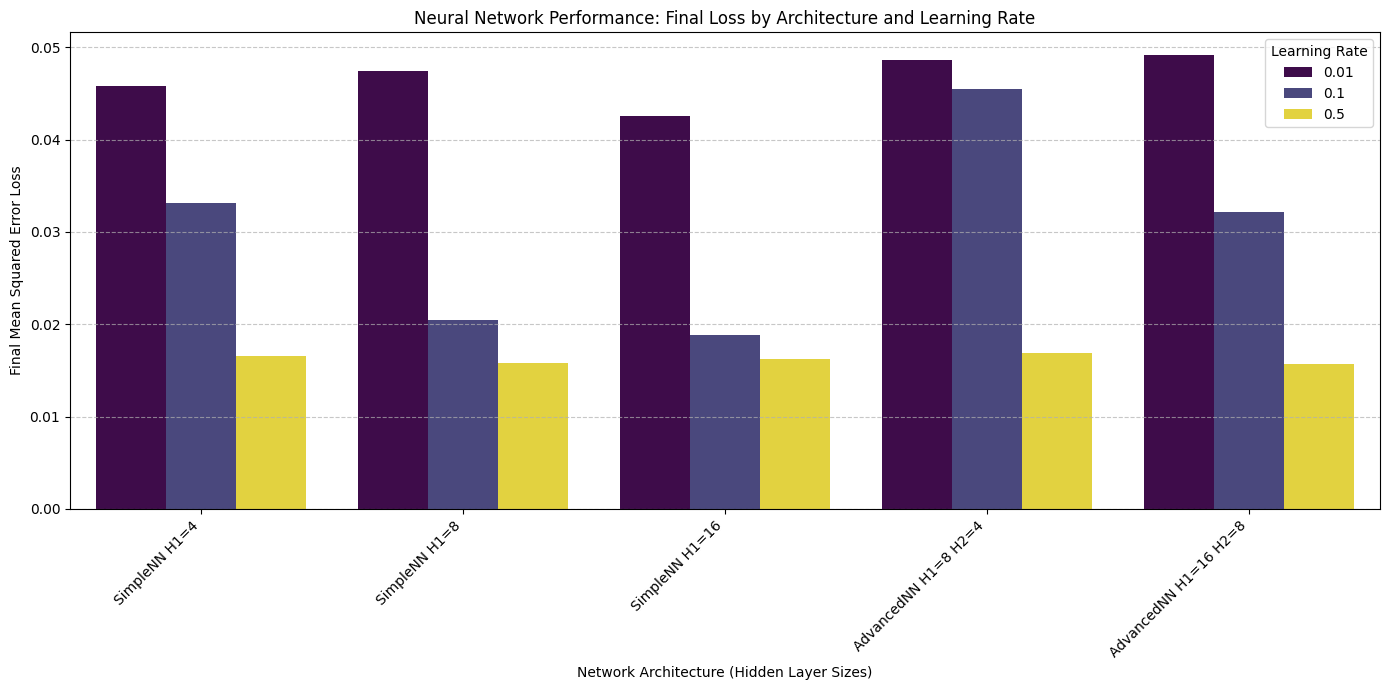

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
# Combine architecture details into a single string for better labeling on the x-axis
results_df['architecture'] = results_df.apply(
    lambda row: f"{row['type']} H1={int(row['hidden_size_1'])}" +
                 (f" H2={int(row['hidden_size_2'])}" if pd.notna(row['hidden_size_2']) else ""),
    axis=1
)

plt.figure(figsize=(14, 7))
sns.barplot(data=results_df, x='architecture', y='final_loss', hue='learning_rate', palette='viridis')
plt.title('Neural Network Performance: Final Loss by Architecture and Learning Rate')
plt.xlabel('Network Architecture (Hidden Layer Sizes)')
plt.ylabel('Final Mean Squared Error Loss')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Learning Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Train and Evaluate Models

### Subtask:
Identify the best performing neural network configuration based on the experimental results, train a new model with these optimal parameters, and evaluate its performance by predicting on the test scenarios.


**Reasoning**:
I will first identify the best performing model configuration from the `results_df` by finding the row with the minimum `final_loss`. This step is crucial for selecting the optimal parameters for the next model training.



In [43]:
import pandas as pd

# Find the best performing model based on the lowest final_loss
best_model_row = results_df.loc[results_df['final_loss'].idxmin()]

# Extract the optimal parameters
optimal_type = best_model_row['type']
optimal_h1 = int(best_model_row['hidden_size_1'])
optimal_h2 = int(best_model_row['hidden_size_2']) if pd.notna(best_model_row['hidden_size_2']) else None
optimal_lr = best_model_row['learning_rate']
optimal_loss = best_model_row['final_loss']

print(f"Best Performing Model Configuration:")
print(f"  Network Type: {optimal_type}")
print(f"  Hidden Layer 1 Size: {optimal_h1}")
if optimal_h2 is not None:
    print(f"  Hidden Layer 2 Size: {optimal_h2}")
print(f"  Learning Rate: {optimal_lr}")
print(f"  Lowest Final Loss: {optimal_loss:.4f}")


Best Performing Model Configuration:
  Network Type: AdvancedNN
  Hidden Layer 1 Size: 16
  Hidden Layer 2 Size: 8
  Learning Rate: 0.5
  Lowest Final Loss: 0.0157


**Reasoning**:
Based on the identified best performing model, I will instantiate the correct network type (SimpleNN or AdvancedNN) with its optimal hidden layer sizes, train it with the generated realistic data, and then predict the social activity probabilities for the test scenarios.




Training best AdvancedNeuralNetwork (H1=16, H2=8, LR=0.5)...
Epoch 0, Loss: 0.0619
Epoch 100, Loss: 0.0466
Epoch 200, Loss: 0.0407
Epoch 300, Loss: 0.0321
Epoch 400, Loss: 0.0236
Epoch 500, Loss: 0.0194
Epoch 600, Loss: 0.0178
Epoch 700, Loss: 0.0173
Epoch 800, Loss: 0.0170
Epoch 900, Loss: 0.0167
Epoch 1000, Loss: 0.0166
Epoch 1100, Loss: 0.0164
Epoch 1200, Loss: 0.0163
Epoch 1300, Loss: 0.0162
Epoch 1400, Loss: 0.0161
Final loss of optimal model: 0.0159


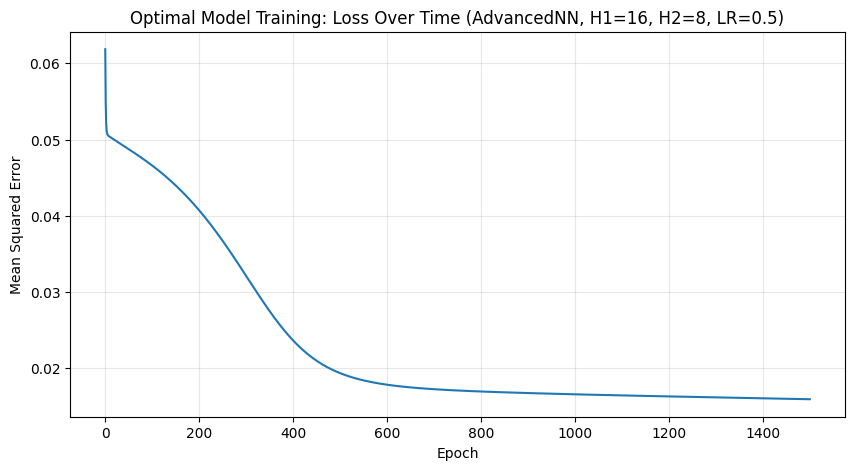


Predictions for test scenarios using the optimal model:
Weekend evening, good weather
  Social activity probability: 88.53%

Weekday morning, poor weather
  Social activity probability: 34.03%

Weekend afternoon, bad weather
  Social activity probability: 62.31%



In [45]:
X_train, y_train = generate_realistic_data(n_samples=2000)

# Instantiate the best performing model
if optimal_type == 'SimpleNN':
    final_model = SimpleNeuralNetwork(input_size=4, hidden_size=optimal_h1, output_size=1)
    print(f"\nTraining best SimpleNeuralNetwork (H1={optimal_h1}, LR={optimal_lr})...")
elif optimal_type == 'AdvancedNN':
    final_model = AdvancedNeuralNetwork(input_size=4, hidden_size_1=optimal_h1, hidden_size_2=optimal_h2, output_size=1)
    print(f"\nTraining best AdvancedNeuralNetwork (H1={optimal_h1}, H2={optimal_h2}, LR={optimal_lr})...")

# Train the model with optimal parameters
final_model.train(X_train, y_train, epochs=1500, learning_rate=optimal_lr)
print(f"Final loss of optimal model: {final_model.loss_history[-1]:.4f}")

# Visualize training progress of the final model
plt.figure(figsize=(10, 5))
plt.plot(final_model.loss_history)
plt.title(f'Optimal Model Training: Loss Over Time ({optimal_type}, H1={optimal_h1}' +
          (f', H2={optimal_h2}' if optimal_h2 is not None else '') + f', LR={optimal_lr})')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True, alpha=0.3)
plt.show()

# Make predictions on test scenarios
print("\nPredictions for test scenarios using the optimal model:")
for name, day, time, weather, mood in scenarios:
    X_test_scenario = normalize_input(day, time, weather, mood)
    prediction = final_model.predict(X_test_scenario)
    print(f"{name}")
    print(f"  Social activity probability: {prediction[0][0]:.2%}\n")